In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import numpy as np

In [2]:
jaundiced_dir = 'jaundiced_normal/Jaundiced Eyes'
normal_dir = 'jaundiced_normal/Normal Eyes'

In [3]:
jaundiced_images = glob.glob(os.path.join(jaundiced_dir, '*.*')) 
normal_images = glob.glob(os.path.join(normal_dir, '*.*')) 

In [4]:
print(f"Number of Jaundiced Eye images: {len(jaundiced_images)}")
print(f"Number of Normal Eye images: {len(normal_images)}")

Number of Jaundiced Eye images: 174
Number of Normal Eye images: 290


In [5]:
df_jaundiced = pd.DataFrame({
    'filepath': jaundiced_images,
    'label': 'Jaundiced'
})


In [6]:
df_normal = pd.DataFrame({
    'filepath': normal_images,
    'label': 'Normal'
})


In [7]:
df = pd.concat([df_jaundiced, df_normal], ignore_index=True)

In [8]:
df = df.sample(frac=1).reset_index(drop=True)

In [9]:
df.head()

,filepath,label
0,jaundiced_normal/Jaundiced Eyes\Image_19.jpg,Jaundiced
1,jaundiced_normal/Normal Eyes\Vision-Changes-to...,Normal
2,jaundiced_normal/Jaundiced Eyes\yellowish-eyes...,Jaundiced
3,jaundiced_normal/Jaundiced Eyes\ems-symptom-wo...,Jaundiced
4,jaundiced_normal/Jaundiced Eyes\yellow-fever-j...,Jaundiced


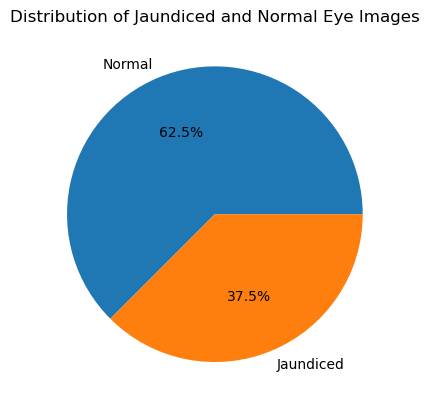

In [11]:
x = df['label'].value_counts()
plt.pie(x.values, labels=x.index, autopct='%1.1f%%')
plt.title('Distribution of Jaundiced and Normal Eye Images')
plt.show()

In [12]:
df_jaundiced_balanced = resample(df_jaundiced, 
                                 replace=True,    
                                 n_samples=len(df_normal),  
                                 random_state=42)

In [13]:
df_balanced = pd.concat([df_jaundiced_balanced, df_normal])

In [14]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [15]:
train_df, val_df = train_test_split(df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['label'])

In [16]:
train_df.head()

,filepath,label
500,jaundiced_normal/Jaundiced Eyes\Image_6 (3).jpg,Jaundiced
0,jaundiced_normal/Normal Eyes\young-old-faces-e...,Normal
295,jaundiced_normal/Normal Eyes\18885510-young-ma...,Normal
228,jaundiced_normal/Normal Eyes\female-eye-elderl...,Normal
469,jaundiced_normal/Jaundiced Eyes\-bilirubin-lev...,Jaundiced


## Data Augmentation for Training and Validation

In [17]:
train_datagen = ImageDataGenerator(rescale=1./255, 
                                   rotation_range=20, 
                                   width_shift_range=0.2, 
                                   height_shift_range=0.2, 
                                   shear_range=0.2, 
                                   zoom_range=0.2, 
                                   horizontal_flip=True, 
                                   fill_mode='nearest')

In [18]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [19]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=(150, 150),  
    batch_size=32,
    class_mode='binary',  
    shuffle=True
)

Found 464 validated image filenames belonging to 2 classes.


In [20]:
val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 116 validated image filenames belonging to 2 classes.


## Data Visualization

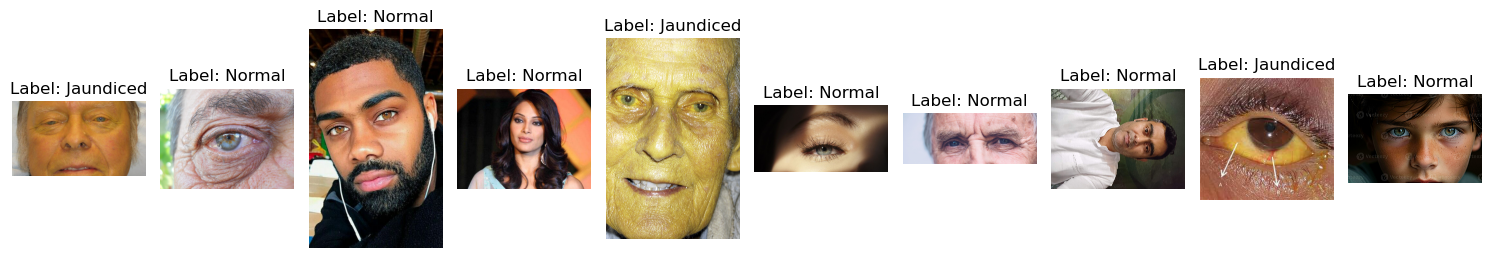

In [21]:
def display_sample_images(df, num_samples=5):
    sample_df = df.sample(n=num_samples, random_state=42)
    
    plt.figure(figsize=(15, 10))
    
    for i, (index, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row['filepath'])
        
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img)
        plt.axis('off')  
        plt.title(f"Label: {row['label']}")
        
    plt.tight_layout()
    plt.show()


display_sample_images(df, num_samples=10)

## Building the Model

In [22]:
def build_model(input_shape=(150, 150, 3)):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    for layer in base_model.layers:
        layer.trainable = False
    
    model = models.Sequential()
    model.add(base_model)  
    model.add(layers.GlobalAveragePooling2D())  
    model.add(layers.Dense(512, activation='relu'))  
    model.add(layers.Dropout(0.5))  
    model.add(layers.Dense(1, activation='sigmoid'))  

    return model

In [23]:
model = build_model()

## Compiling the Model

In [24]:
model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

In [25]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 512)               262656    
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 513       
                                                                 
Total params: 14,977,857
Trainable params: 263,169
Non-trainable params: 14,714,688
______________________________________

## Model Training

In [26]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', 
                                                  patience=5, 
                                                  restore_best_weights=True)

In [27]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

Epoch 1/10
15/15 [==============================] - 54s 4s/step - loss: 0.7064 - accuracy: 0.5366 - val_loss: 0.6851 - val_accuracy: 0.5776
Epoch 2/10
15/15 [==============================] - 52s 3s/step - loss: 0.7121 - accuracy: 0.5323 - val_loss: 0.6658 - val_accuracy: 0.6293
Epoch 3/10
15/15 [==============================] - 52s 3s/step - loss: 0.6822 - accuracy: 0.5733 - val_loss: 0.6478 - val_accuracy: 0.6466
Epoch 4/10
15/15 [==============================] - 56s 4s/step - loss: 0.6643 - accuracy: 0.5927 - val_loss: 0.6321 - val_accuracy: 0.6293
Epoch 5/10
15/15 [==============================] - 54s 4s/step - loss: 0.6528 - accuracy: 0.6013 - val_loss: 0.6158 - val_accuracy: 0.6466
Epoch 6/10
15/15 [==============================] - 51s 4s/step - loss: 0.6554 - accuracy: 0.6272 - val_loss: 0.6000 - val_accuracy: 0.7069
Epoch 7/10
15/15 [==============================] - 51s 3s/step - loss: 0.6263 - accuracy: 0.6466 - val_loss: 0.5874 - val_accuracy: 0.7069
Epoch 8/10
15/15 [==

## Model Evaluation

In [28]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

4/4 [==============================] - 11s 2s/step - loss: 0.5583 - accuracy: 0.7155
Validation Loss: 0.5583
Validation Accuracy: 0.7155


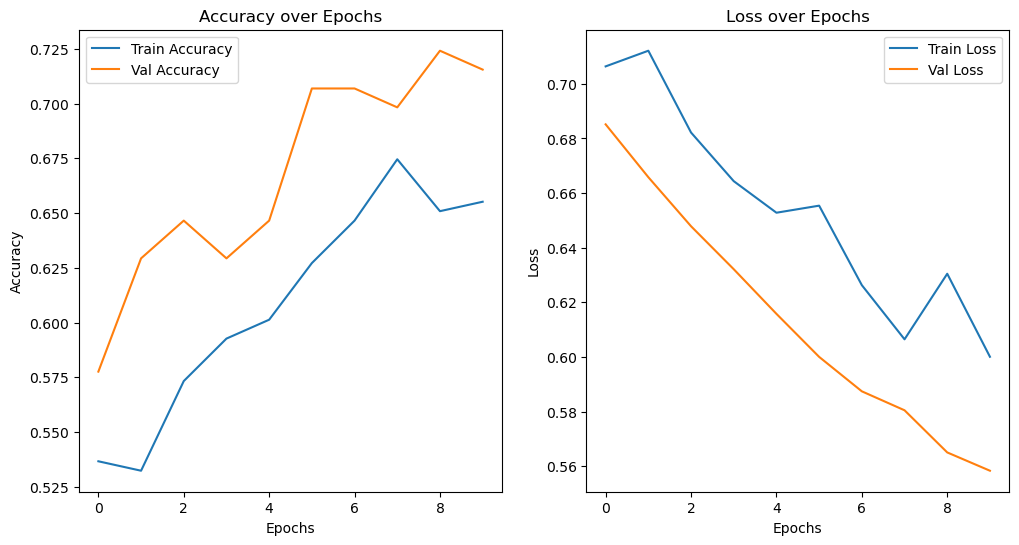

In [29]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

1/1 [==============================] - 0s 338ms/step


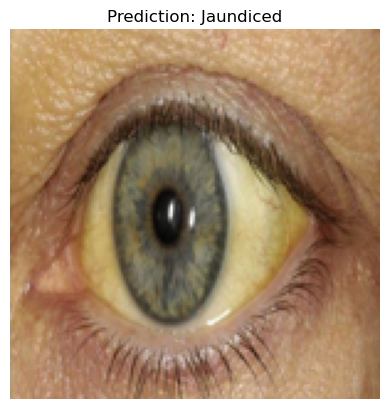

In [30]:
def display_image_with_prediction(image_path, model):
    img = Image.open(image_path)
    img_resized = img.resize((150, 150))  
    img_array = np.array(img_resized) / 255.0  
    img_array = np.expand_dims(img_array, axis=0) 
    
    prediction = model.predict(img_array)
    predicted_label = "Jaundiced" if prediction[0] < 0.5 else "Normal"
    
    plt.imshow(img_resized)
    plt.axis('off')  
    plt.title(f"Prediction: {predicted_label}")
    plt.show()


image_path = "C:\\Users\\User\\jaundiced_normal\\Jaundiced Eyes\\10-penyebab-mata-kuning-dan-cara-memuti-10d46f (2).jpg"  # Replace with the actual path to the image
display_image_with_prediction(image_path, model)

## Hyperparameter Tuning with PSO

In [42]:
from pyswarm import pso


def objective_function(params):
    
    learning_rate, batch_size = params[0], int(params[1])
    model = build_model(input_shape=(150, 150, 3))
    
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    
    
    history = model.fit(train_generator,
                        epochs=1,
                        batch_size=batch_size,
                        validation_data=val_generator)
    
    
    val_loss = history.history['val_loss'][-1]
    return val_loss


lb = [1e-5, 16]  
ub = [1e-2, 64]  


best_params, _ = pso(objective_function, lb, ub, swarmsize=1, maxiter=1)

print(f"Best Hyperparameters: Learning rate = {best_params[0]}, Batch size = {int(best_params[1])}")

15/15 [==============================] - 51s 3s/step - loss: 0.8497 - accuracy: 0.5129 - val_loss: 0.5931 - val_accuracy: 0.7069
Stopping search: maximum iterations reached --> 1
Best Hyperparameters: Learning rate = 0.004693802482879609, Batch size = 27


In [43]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

4/4 [==============================] - 10s 2s/step - loss: 0.5583 - accuracy: 0.7155
Validation Loss: 0.5583
Validation Accuracy: 0.7155


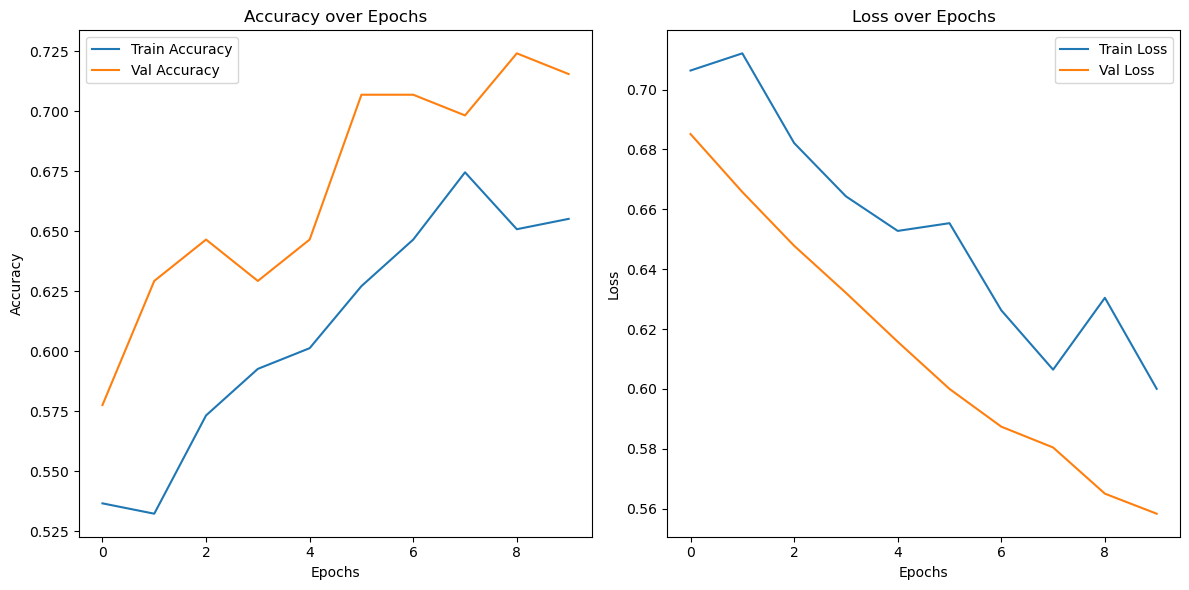

In [44]:
plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 108ms/step


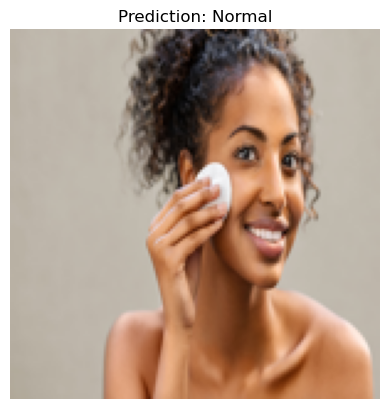

In [49]:
image_path = "C:\\Users\\User\\jaundiced_normal\\Normal Eyes\\2a.jpg"
display_image_with_prediction(image_path, model)